# Лабораторный практикум по курсу «Разговорный ИИ и большие языковые модели», Университет ИТМО, 2026
**Лабораторная работа №1.**

**Цель работы:** Обучить модель векторизации на задаче мультиклассовой классификации текстов

## Baseline

### 0. Импорт библиотек

In [1]:
import os
import gc
import time
import torch
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score


### Инициализация и загрузка модели и датасета

In [2]:
DATA_DIR  = r"C:/Users/Landi/Downloads"
OUT_DIR   = "."   
CKPT_DIR  = os.path.join(OUT_DIR, "embeddings_ckpt")
os.makedirs(CKPT_DIR, exist_ok=True)

TRAIN_PARQUET = os.path.join(DATA_DIR, "train-00000-of-00001.parquet")
TEST_PARQUET  = os.path.join(DATA_DIR, "test-00000-of-00001.parquet")

MODEL_NAME  = "distilbert-base-uncased"
MAX_LENGTH  = 128
BATCH_SIZE  = 32

print("train parquet:", TRAIN_PARQUET)
print("test  parquet:", TEST_PARQUET)
print("ckpt dir:     ", CKPT_DIR)

train parquet: C:/Users/Landi/Downloads\train-00000-of-00001.parquet
test  parquet: C:/Users/Landi/Downloads\test-00000-of-00001.parquet
ckpt dir:      .\embeddings_ckpt


### Основные параметры корпуса данных

In [3]:
train_df = pd.read_parquet(TRAIN_PARQUET)
test_df  = pd.read_parquet(TEST_PARQUET)

train_texts = train_df["text"].tolist()
test_texts  = test_df["text"].tolist()
y_train     = train_df["label"].values
y_test      = test_df["label"].values

print("train:", len(train_texts))
print("test: ", len(test_texts))
print()
print(train_df["label"].value_counts().sort_index())

train: 120000
test:  7600

label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

print("Класс:        ", type(model).__name__)
print("Слоёв:        ", model.config.num_hidden_layers)
print("hidden_size:  ", model.config.hidden_size)
print("max_position: ", model.config.max_position_embeddings)
print("vocab_size:   ", model.config.vocab_size)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Класс:         DistilBertModel
Слоёв:         6
hidden_size:   768
max_position:  512
vocab_size:    30522


### Получение эмбеддингов для Train-выборки

In [ ]:
# Train
TAG        = "train_full"
BATCH_SIZE = 32
MAX_LENGTH = 128

for f in os.listdir(CKPT_DIR):
    if f.startswith(f"{TAG}_part"):
        os.remove(os.path.join(CKPT_DIR, f))

n = len(train_texts)
t0 = time.time()
pbar = tqdm(range(0, n, BATCH_SIZE), desc=f"[{TAG}]")
mean_paths, cls_paths = [], []

for bi, i in enumerate(pbar):
    batch = train_texts[i:i + BATCH_SIZE]

    encoded = tokenizer(
        batch, return_tensors="pt",
        padding=True, truncation=True, max_length=MAX_LENGTH,
    )
    with torch.no_grad():
        out = model(**encoded)

    hidden = out.last_hidden_state
    mask_f = encoded["attention_mask"].unsqueeze(-1).float()
    mean_v = ((hidden * mask_f).sum(1) / mask_f.sum(1).clamp(min=1e-9)).cpu().numpy()
    cls_v  = hidden[:, 0, :].cpu().numpy()

    part = i // BATCH_SIZE
    mean_file = os.path.join(CKPT_DIR, f"{TAG}_part{part:05d}_mean.npy")
    cls_file  = os.path.join(CKPT_DIR, f"{TAG}_part{part:05d}_cls.npy")
    np.save(mean_file, mean_v)
    np.save(cls_file,  cls_v)
    mean_paths.append(mean_file)
    cls_paths.append(cls_file)

    del out, encoded, hidden, mask_f, mean_v, cls_v
    gc.collect()

    if bi % 10 == 0:
        done = min(i + BATCH_SIZE, n)
        elapsed = time.time() - t0
        rate = done / elapsed if elapsed > 0 else 0
        eta_min = (n - done) / rate / 60 if rate > 0 else 0
        pbar.set_postfix({"rate": f"{rate:.1f} tx/s", "eta": f"{eta_min:.1f} min"})

def assemble_incremental(paths, out_file):
    first = np.load(paths[0])
    H = first.shape[1]
    total_rows = sum(np.load(p, mmap_mode="r").shape[0] for p in paths)

    out = np.empty((total_rows, H), dtype=first.dtype)
    pos = 0
    for p in tqdm(paths, desc=f"Сборка {os.path.basename(out_file)}"):
        part = np.load(p)
        out[pos:pos + part.shape[0]] = part
        pos += part.shape[0]
        del part
    np.save(out_file, out)
    return out

print("\nСборка mean...")
X_train_mean = assemble_incremental(
    mean_paths, os.path.join(OUT_DIR, "X_train_mean.npy")
)
print("X_train_mean:", X_train_mean.shape)

print("\nСборка cls...")
X_train_cls = assemble_incremental(
    cls_paths, os.path.join(OUT_DIR, "X_train_cls.npy")
)
print("X_train_cls: ", X_train_cls.shape)

np.save(os.path.join(OUT_DIR, "y_train.npy"), y_train)
print("y_train:     ", y_train.shape)
print(f"\nВремя выполнения: {(time.time() - t0) / 60:.1f} мин")

[train_full]:   0%|          | 0/3750 [00:00<?, ?it/s]


Сборка mean...


Сборка X_train_mean.npy:   0%|          | 0/3750 [00:00<?, ?it/s]

X_train_mean: (120000, 768)

Сборка cls...


Сборка X_train_cls.npy:   0%|          | 0/3750 [00:00<?, ?it/s]

X_train_cls:  (120000, 768)
y_train:      (120000,)

Время выполнения: 61.0 мин


### Получение эмбеддингов для Test-выборки

In [9]:
TAG = "test_full"

# Чистим старые файлы этого тега
for f in os.listdir(CKPT_DIR):
    if f.startswith(f"{TAG}_part"):
        os.remove(os.path.join(CKPT_DIR, f))

n = len(test_texts)
t0 = time.time()
pbar = tqdm(range(0, n, BATCH_SIZE), desc=f"[{TAG}]")
mean_paths, cls_paths = [], []

for bi, i in enumerate(pbar):
    batch = test_texts[i:i + BATCH_SIZE]

    encoded = tokenizer(
        batch, return_tensors="pt",
        padding=True, truncation=True, max_length=MAX_LENGTH,
    )
    with torch.no_grad():
        out = model(**encoded)

    hidden = out.last_hidden_state
    mask_f = encoded["attention_mask"].unsqueeze(-1).float()
    mean_v = ((hidden * mask_f).sum(1) / mask_f.sum(1).clamp(min=1e-9)).cpu().numpy()
    cls_v  = hidden[:, 0, :].cpu().numpy()

    part = i // BATCH_SIZE
    mean_file = os.path.join(CKPT_DIR, f"{TAG}_part{part:05d}_mean.npy")
    cls_file  = os.path.join(CKPT_DIR, f"{TAG}_part{part:05d}_cls.npy")
    np.save(mean_file, mean_v)
    np.save(cls_file,  cls_v)
    mean_paths.append(mean_file)
    cls_paths.append(cls_file)

    del out, encoded, hidden, mask_f, mean_v, cls_v
    gc.collect()

    if bi % 10 == 0:
        done = min(i + BATCH_SIZE, n)
        elapsed = time.time() - t0
        rate = done / elapsed if elapsed > 0 else 0
        eta_min = (n - done) / rate / 60 if rate > 0 else 0
        pbar.set_postfix({"rate": f"{rate:.1f} tx/s", "eta": f"{eta_min:.1f} min"})

print("\nСборка mean...")
X_test_mean = assemble_incremental(
    mean_paths, os.path.join(OUT_DIR, "X_test_mean.npy")
)
print("X_test_mean:", X_test_mean.shape)

print("\nСборка cls...")
X_test_cls = assemble_incremental(
    cls_paths, os.path.join(OUT_DIR, "X_test_cls.npy")
)
print("X_test_cls: ", X_test_cls.shape)

np.save(os.path.join(OUT_DIR, "y_test.npy"), y_test)
print("y_test:     ", y_test.shape)
print(f"\nВремя выполнения: {(time.time() - t0) / 60:.1f} мин")

[test_full]:   0%|          | 0/238 [00:00<?, ?it/s]


Сборка mean...


Сборка X_test_mean.npy:   0%|          | 0/238 [00:00<?, ?it/s]

X_test_mean: (7600, 768)

Сборка cls...


Сборка X_test_cls.npy:   0%|          | 0/238 [00:00<?, ?it/s]

X_test_cls:  (7600, 768)
y_test:      (7600,)

Время выполнения: 4.4 мин


### 3-4. Обучение классификатора LogisticRegression с mean_pooling и подсчет метрик: F1-Score, Precision, Recall. 

In [ ]:
clf_mean = LogisticRegression(max_iter=1000, n_jobs=-1)
clf_mean.fit(X_train_mean, y_train)

y_pred_mean = clf_mean.predict(X_test_mean)

print("Mean pooling")
print(f"F1 (macro):        {f1_score(y_test, y_pred_mean, average='macro'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_mean, average='macro'):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_mean, average='macro'):.4f}")
print()
print(classification_report(
    y_test, y_pred_mean,
    target_names=["World", "Sports", "Business", "Sci/Tech"],
))

c:\Users\Landi\ИТМО\2 сем\NLP\nlp_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Mean pooling
F1 (macro):        0.9156
Precision (macro): 0.9157
Recall (macro):    0.9157

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.97      0.99      0.98      1900
    Business       0.87      0.88      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



### 5-6. Обучение классификатора LogisticRegression с cls_pooling и подсчет метрик: F1-Score, Precision, Recall. 

In [31]:
clf_cls = LogisticRegression(max_iter=2000, n_jobs=-1)
clf_cls.fit(X_train_cls, y_train)

y_pred_cls = clf_cls.predict(X_test_cls)

print(" cls pooling")
print(f"F1 (macro):        {f1_score(y_test, y_pred_cls, average='macro'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_cls, average='macro'):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_cls, average='macro'):.4f}")
print()
print(classification_report(
    y_test, y_pred_cls,
    target_names=["World", "Sports", "Business", "Sci/Tech"],
))

c:\Users\Landi\ИТМО\2 сем\NLP\nlp_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


 cls pooling
F1 (macro):        0.9123
Precision (macro): 0.9123
Recall (macro):    0.9124

              precision    recall  f1-score   support

       World       0.92      0.90      0.91      1900
      Sports       0.97      0.98      0.98      1900
    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



## Сравнительный анализ

In [ ]:
comparison = pd.DataFrame({
    "Метрика":          ["F1 (macro)", "Precision (macro)", "Recall (macro)"],
    "Mean pooling": [
        f1_score(y_test, y_pred_mean, average="macro"),
        precision_score(y_test, y_pred_mean, average="macro"),
        recall_score(y_test, y_pred_mean, average="macro"),
    ],
    "CLS pooling": [
        f1_score(y_test, y_pred_cls, average="macro"),
        precision_score(y_test, y_pred_cls, average="macro"),
        recall_score(y_test, y_pred_cls, average="macro"),
    ],
})
comparison["Разница (CLS − Mean)"] = (
    comparison["CLS pooling"] - comparison["Mean pooling"]
)
comparison = comparison.round(4)
print(comparison.to_string(index=False))

          Метрика  Mean pooling  CLS pooling  Разница (CLS − Mean)
       F1 (macro)        0.9156       0.9123               -0.0033
Precision (macro)        0.9157       0.9123               -0.0034
   Recall (macro)        0.9157       0.9124               -0.0033


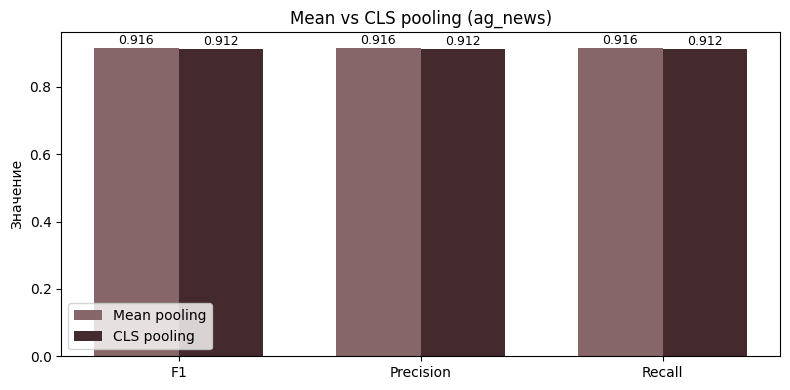

In [ ]:
metrics = ["F1", "Precision", "Recall"]
mean_scores = [
    f1_score(y_test, y_pred_mean, average="macro"),
    precision_score(y_test, y_pred_mean, average="macro"),
    recall_score(y_test, y_pred_mean, average="macro"),
]
cls_scores = [
    f1_score(y_test, y_pred_cls, average="macro"),
    precision_score(y_test, y_pred_cls, average="macro"),
    recall_score(y_test, y_pred_cls, average="macro"),
]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, mean_scores, w, label="Mean pooling", color="#866668")
b2 = ax.bar(x + w/2, cls_scores,  w, label="CLS pooling",  color="#44292D")

for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Значение")
ax.set_title("Mean vs CLS pooling (ag_news)")
ax.legend()
plt.tight_layout()
plt.show()

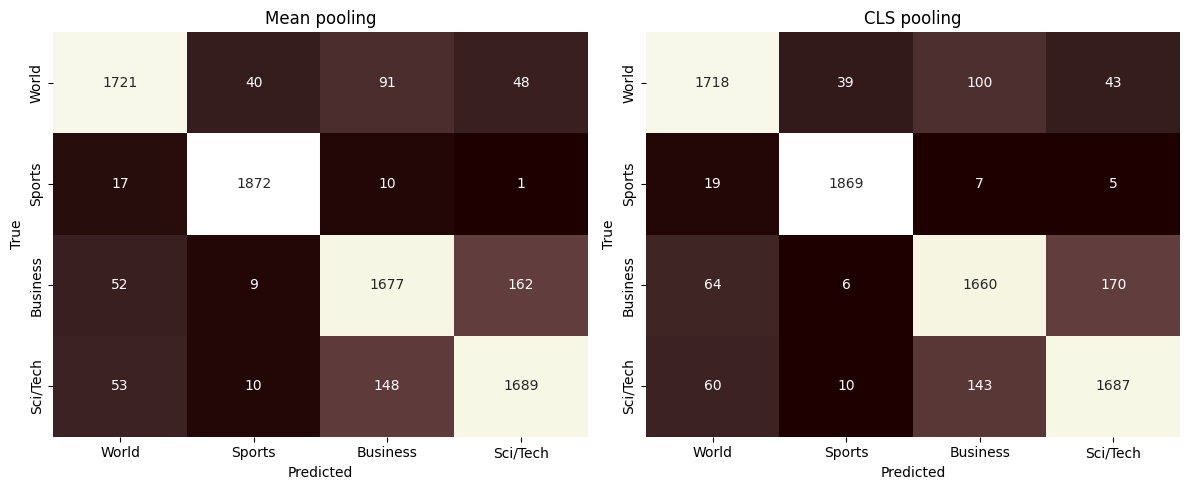

In [ ]:
class_names = ["World", "Sports", "Business", "Sci/Tech"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_mean, y_pred_cls],
    ["Mean pooling", "CLS pooling"],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="pink",
                xticklabels=class_names, yticklabels=class_names,
                cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()